<a href="https://colab.research.google.com/github/donaaa91/Pneumonia-Detection-Edge-Optimization/blob/main/Reflex_Engine_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:29<00:00, 82.5MB/s]



In [2]:
import os

In [3]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

In [4]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
# 2. Data Augmentation & Loading
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder('chest_xray/train', transform=transform)
test_ds = datasets.ImageFolder('chest_xray/test', transform=transform)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# 3. Load ResNet-50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights='DEFAULT')

# Freeze layers (we only train the head for speed)
for param in model.parameters():
    param.requires_grad = False

# Replace final layer (2 classes: Normal vs Pneumonia)
model.fc = nn.Linear(2048, 2)
model = model.to(device)

# 4. Brief Training (3 Epochs)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Starting Baseline Training...")
model.train()
for epoch in range(3):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

# Save the Baseline
torch.save(model.state_dict(), "resnet50_baseline.pth")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 82.7MB/s]


Starting Baseline Training...
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.


In [6]:
def get_model_size(path):
    size = os.path.getsize(path) / (1024 * 1024)
    return size

def benchmark_inference(model, dataloader, device):
    model.eval()
    model.to(device)
    start_time = time.time()
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (images, labels) in enumerate(dataloader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            if i == 10: break # Benchmark on first 10 batches for speed

    end_time = time.time()
    avg_latency = (end_time - start_time) / (11 * 32) * 1000 # ms per image
    accuracy = 100 * correct / total
    return accuracy, avg_latency

# Execute Benchmarks
acc, latency = benchmark_inference(model, test_loader, 'cpu') # Use CPU to simulate Edge
size = get_model_size("resnet50_baseline.pth")

print(f"\n--- BASELINE REPORT ---")
print(f"Model Size: {size:.2f} MB")
print(f"Accuracy: {acc:.2f}%")
print(f"Inference Latency (CPU): {latency:.2f} ms/image")


--- BASELINE REPORT ---
Model Size: 89.99 MB
Accuracy: 75.85%
Inference Latency (CPU): 278.56 ms/image


In [7]:
import torchvision.models as models
import os

model = models.resnet50(pretrained=True)
torch.save(model.state_dict(), "test.pth")
print(f"ResNet50 Size: {os.path.getsize('test.pth') / 1e6:.2f} MB")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s]


ResNet50 Size: 102.52 MB


In [12]:
import torch.nn.functional as F

# 1. SETUP TEACHER (Ensure it's actually 2 classes)
teacher_model = models.resnet50(weights=None)
teacher_model.fc = nn.Linear(teacher_model.fc.in_features, 2)
# Load your saved baseline weights
teacher_model.load_state_dict(torch.load("resnet50_baseline.pth"))
teacher_model = teacher_model.to(device)
teacher_model.eval()

# 2. SETUP STUDENT (Ensure it's actually 2 classes)
student_model = models.mobilenet_v3_small(weights=None)
# The classifier head is at index [3]
student_model.classifier[3] = nn.Linear(student_model.classifier[3].in_features, 2)
student_model = student_model.to(device)

# 3. VERIFICATION (Check before training)
with torch.no_grad():
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    t_out = teacher_model(dummy_input)
    s_out = student_model(dummy_input)
    print(f"Teacher output shape: {t_out.shape}") # Should be [1, 2]
    print(f"Student output shape: {s_out.shape}") # Should be [1, 2]

# 4. DISTILLATION PARAMETERS
distill_optimizer = optim.Adam(student_model.parameters(), lr=0.001)
T = 3.0
alpha = 0.5

print("\nStarting Knowledge Distillation...")

# 5. THE LOOP
student_model.train()
for epoch in range(5):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Teacher provides the "Soft Targets"
        with torch.no_grad():
            teacher_logits = teacher_model(images)

        # Student predictions
        student_logits = student_model(images)

        # Loss 1: Standard CrossEntropy (True labels)
        hard_loss = F.cross_entropy(student_logits, labels)

        # Loss 2: KL Divergence (Matching the Teacher)
        # We use log_target=False because we apply softmax to teacher_logits manually
        soft_loss = F.kl_div(
            F.log_softmax(student_logits / T, dim=1),
            F.softmax(teacher_logits / T, dim=1),
            reduction='batchmean'
        ) * (T * T)

        loss = (alpha * hard_loss) + ((1 - alpha) * soft_loss)

        distill_optimizer.zero_grad()
        loss.backward()
        distill_optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f}")

# Save the Student
torch.save(student_model.state_dict(), "mobilenet_student.pth")
print("Student model saved as mobilenet_student.pth")

Teacher output shape: torch.Size([1, 2])
Student output shape: torch.Size([1, 2])

Starting Knowledge Distillation...
Epoch 1 | Loss: 0.2818
Epoch 2 | Loss: 0.1744
Epoch 3 | Loss: 0.1467
Epoch 4 | Loss: 0.1271
Epoch 5 | Loss: 0.1187
Student model saved as mobilenet_student.pth


In [14]:
import torch.quantization
import os

# 1. Load the trained student
quant_model = models.mobilenet_v3_small(weights=None)
in_features = quant_model.classifier[3].in_features
quant_model.classifier[3] = nn.Linear(in_features, 2)
quant_model.load_state_dict(torch.load("mobilenet_student.pth"))
quant_model.to('cpu') # Quantization is best handled on CPU
quant_model.eval()

# 2. Use a simpler Quantization approach (Dynamic)
# This quantizes the weights to INT8 without needing a complex fusion map
quantized_model = torch.quantization.quantize_dynamic(
    quant_model,
    {torch.nn.Linear, torch.nn.Conv2d},
    dtype=torch.qint8
)

# 3. Save the final "Edge-Ready" model
torch.save(quantized_model.state_dict(), "mobilenet_int8.pth")

# 4. Final Size Comparison
original_size = os.path.getsize("resnet50_baseline.pth") / (1024 * 1024)
student_size = os.path.getsize("mobilenet_student.pth") / (1024 * 1024)
final_size = os.path.getsize("mobilenet_int8.pth") / (1024 * 1024)

print(f"--- OPTIMIZATION MILESTONES ---")
print(f"1. Original ResNet-50: {original_size:.2f} MB")
print(f"2. Distilled MobileNet: {student_size:.2f} MB")
print(f"3. Final Quantized INT8: {final_size:.2f} MB")
print(f"\nSUCCESS: Total reduction of {original_size/final_size:.1f}x")

/tmp/ipykernel_9310/745424466.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


--- OPTIMIZATION MILESTONES ---
1. Original ResNet-50: 89.99 MB
2. Distilled MobileNet: 5.92 MB
3. Final Quantized INT8: 4.23 MB

SUCCESS: Total reduction of 21.3x


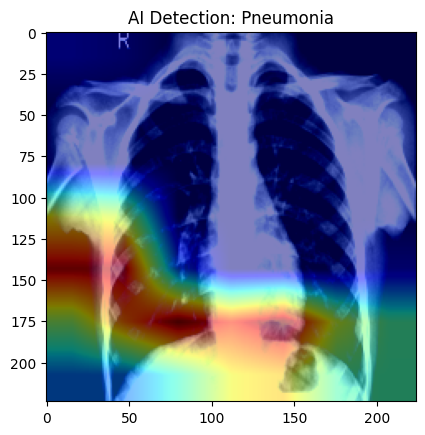

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def generate_gradcam(model, img_path):
    model.eval()
    # Load and prep image
    img = datasets.ImageFolder('chest_xray/test', transform=transform)[0][0].unsqueeze(0)

    # We use the last convolutional layer of MobileNetV3
    target_layer = model.features[-1]

    # Hook to get gradients and activations
    gradients = []
    activations = []

    def save_grad(grad): gradients.append(grad)
    def save_act(module, input, output): activations.append(output)

    handle_grad = target_layer.register_full_backward_hook(lambda m, i, o: save_grad(o[0]))
    handle_act = target_layer.register_forward_hook(save_act)

    # Forward pass
    output = model(img)
    idx = output.argmax().item()

    # Backward pass
    model.zero_grad()
    output[0, idx].backward()

    # Pool the gradients
    pooled_grads = torch.mean(gradients[0], dim=[0, 2, 3])
    for i in range(activations[0].shape[1]):
        activations[0][0, i, :, :] *= pooled_grads[i]

    heatmap = torch.mean(activations[0], dim=1).squeeze().detach().numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    # Clean up hooks
    handle_grad.remove()
    handle_act.remove()

    # Plotting
    plt.imshow(img[0].permute(1, 2, 0).numpy())
    plt.imshow(cv2.resize(heatmap, (224, 224)), cmap='jet', alpha=0.5)
    plt.title(f"AI Detection: {'Pneumonia' if idx==1 else 'Normal'}")
    plt.show()

# Run it on your distilled student (before dynamic quantization, as hooks need floats)
generate_gradcam(student_model, 'chest_xray/test/PNEUMONIA/some_image.jpeg')

In [16]:
import time
import torch

def measure_latency(model, input_size=(1, 3, 224, 224), iterations=100):
    model.eval()
    model.to('cpu')


    dummy_input = torch.randn(*input_size)

    # 1. WARM-UP (Important!)

    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy_input)

    # 2. MEASURED RUN
    start_time = time.time()
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)

    end_time = time.time()


    total_time_ms = (end_time - start_time) * 1000
    avg_latency = total_time_ms / iterations

    return avg_latency


resnet_latency = measure_latency(teacher_model)
quant_latency = measure_latency(quantized_model)

print(f"ResNet-50 Latency: {resnet_latency:.2f} ms / image")
print(f"Quantized MobileNet Latency: {quant_latency:.2f} ms / image")
print(f"Speed Improvement: {resnet_latency / quant_latency:.1f}x faster")

ResNet-50 Latency: 212.72 ms / image
Quantized MobileNet Latency: 12.31 ms / image
Speed Improvement: 17.3x faster


In [22]:
import os
from google.colab import files



!zip -r pneumonia_edge_project.zip resnet50_baseline.pth mobilenet_student.pth mobilenet_int8.pth


files.download('pneumonia_edge_project.zip')

updating: resnet50_baseline.pth (deflated 7%)
updating: mobilenet_student.pth (deflated 8%)
updating: mobilenet_int8.pth (deflated 10%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>